In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
# Load dataset (portable relative path)
df = pd.read_csv("Master Thesis Survey (Responses).csv")

In [ ]:


# Correct rename mapping matching actual CSV column names
df = df.rename(columns={
    'Section 1 (1 = Strongly Disagree, 5 = Strongly Agree) [I am very concerned about my health.]': 'HO1',
    'Section 1 (1 = Strongly Disagree, 5 = Strongly Agree) [I actively try to eat and drink healthy foods.]': 'HO2',
    'Section 1 (1 = Strongly Disagree, 5 = Strongly Agree) [I regularly read nutrition labels.]': 'HO3',
    'Section 1 (1 = Strongly Disagree, 5 = Strongly Agree) [I try to prevent health problems through my lifestyle.]': 'HO4',

    'Section 2 (1 = Strongly Disagree, 5 = Strongly Agree) [Functional beverages are beneficial for health.]': 'AT1',
    'Section 2 (1 = Strongly Disagree, 5 = Strongly Agree) [Functional beverages are mostly marketing hype.]': 'AT2',
    'Section 2 (1 = Strongly Disagree, 5 = Strongly Agree) [I trust the health claims of functional beverages.]': 'AT3',
    'Section 2 (1 = Strongly Disagree, 5 = Strongly Agree) [Functional beverages are unnecessary for me.]': 'AT4',
    'Section 2 (1 = Strongly Disagree, 5 = Strongly Agree) [Functional beverages are not worth their price.]': 'AT5',

    'Section 3 (1 = Strongly Disagree, 5 = Strongly Agree) [Functional beverages can improve overall wellbeing.]': 'BR1',
    'Section 3 (1 = Strongly Disagree, 5 = Strongly Agree) [I worry about artificial ingredients in functional beverages.]': 'BR2',
    'Section 3 (1 = Strongly Disagree, 5 = Strongly Agree) [I am unsure whether functional beverages really work.]': 'BR3',
    'Section 3 (1 = Strongly Disagree, 5 = Strongly Agree) [Functional beverages seem safe to consume.]': 'BR4',
    'Section 3 (1 = Strongly Disagree, 5 = Strongly Agree) [I feel regular foods provide enough nutrients.]': 'BR5',

    'Section 4 (1 = Strongly Disagree, 5 = Strongly Agree) [My friends rarely consume functional beverages.]': 'SN1',
    'Section 4 (1 = Strongly Disagree, 5 = Strongly Agree) [My family does not encourage me to consume functional beverages.]': 'SN2',
    'Section 4 (1 = Strongly Disagree, 5 = Strongly Agree) [People important to me think functional beverages are unnecessary.]': 'SN3',
    'Section 4 (1 = Strongly Disagree, 5 = Strongly Agree) [I see functional beverages as popular among people my age.]': 'SN4',

    'Section 5 (1 = Strongly Disagree, 5 = Strongly Agree) [Functional beverages are too expensive.]': 'PBC1',
    'Section 5 (1 = Strongly Disagree, 5 = Strongly Agree) [I find functional beverage labels confusing.]': 'PBC2',
    "Section 5 (1 = Strongly Disagree, 5 = Strongly Agree) [I don\u2019t know which functional beverage to choose.]": 'PBC3',
    'Section 5 (1 = Strongly Disagree, 5 = Strongly Agree) [Functional beverages are not easily available where I shop.]': 'PBC4',
    'Section 5 (1 = Strongly Disagree, 5 = Strongly Agree) [I do not have enough information about functional beverages.]': 'PBC5',

    'Section 6 (1 = Strongly Disagree, 5 = Strongly Agree) [I like trying new food and beverage products.]': 'INNO1',
    'Section 6 (1 = Strongly Disagree, 5 = Strongly Agree) [I prefer to stick with products I already know.]': 'INNO2',
    'Section 6 (1 = Strongly Disagree, 5 = Strongly Agree) [I am cautious about new health products.]': 'INNO3',
    'Section 6 (1 = Strongly Disagree, 5 = Strongly Agree) [I enjoy experimenting with new drinks.]': 'INNO4',

    'Section 7 (1 = Strongly Disagree, 5 = Strongly Agree) [I do not plan to purchase functional beverages.]': 'INT1',
    'Section 7 (1 = Strongly Disagree, 5 = Strongly Agree) [I intend to avoid functional beverages in the future.]': 'INT2',
    'Section 7 (1 = Strongly Disagree, 5 = Strongly Agree) [I prefer regular beverages over functional beverages.]': 'INT3',

    'Section 8 (1 = Strongly Disagree, 5 = Strongly Agree) [I rarely or never purchase functional beverages.]': 'BEH1',
    'Section 8 (1 = Strongly Disagree, 5 = Strongly Agree) [I usually ignore functional beverages in stores.]': 'BEH2',
    'Section 8 (1 = Strongly Disagree, 5 = Strongly Agree) [I choose other beverages instead.]': 'BEH3',
})

# Keep only survey columns
survey_cols = ['HO1','HO2','HO3','HO4',
               'AT1','AT2','AT3','AT4','AT5',
               'BR1','BR2','BR3','BR4','BR5',
               'SN1','SN2','SN3','SN4',
               'PBC1','PBC2','PBC3','PBC4','PBC5',
               'INNO1','INNO2','INNO3','INNO4',
               'INT1','INT2','INT3',
               'BEH1','BEH2','BEH3']

df = df[survey_cols]

# Convert text Likert responses to numbers (handles mixed text/numeric data)
likert_map = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5
}
df = df.replace(likert_map)

# Convert to numeric (coerces any remaining non-numeric to NaN)
df = df.apply(pd.to_numeric, errors='coerce')

# Fill missing values with column mean
df = df.fillna(df.mean())

# Reverse coding
reverse_cols = ['AT1','AT3','BR1','BR4','SN4','INNO1','INNO4']
for col in reverse_cols:
    df[col] = 6 - df[col]

/tmp/ipykernel_147/4041407468.py:69: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(likert_map)


In [ ]:


# Predictor variables
X = df[['HO1','HO2','HO3','HO4',
        'AT1','AT2','AT3',
        'BR1','BR2','BR3','BR4',
        'SN1','SN2','SN4',
        'PBC1','PBC2','PBC3','PBC4',
        'INNO1','INNO2','INNO4']]

# Target variable
y = df[['INT1','INT2','INT3','BEH1','BEH2','BEH3']].mean(axis=1)
y = y.apply(lambda x: 1 if x >= 4 else 0)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic regression model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


In [ ]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
importance = pd.DataFrame({
    'Feature': ['HO1','HO2','HO3','HO4',
                'AT1','AT2','AT3',
                'BR1','BR2','BR3','BR4',
                'SN1','SN2','SN4',
                'PBC1','PBC2','PBC3','PBC4',
                'INNO1','INNO2','INNO4'],
    'Coefficient': model.coef_[0]
})

print("\nFeature Importance:")
print(importance.sort_values(by='Coefficient', ascending=False))

Accuracy: 0.8333333333333334

Confusion Matrix:
[[13  2]
 [ 1  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        15
           1       0.50      0.67      0.57         3

    accuracy                           0.83        18
   macro avg       0.71      0.77      0.73        18
weighted avg       0.86      0.83      0.84        18


Feature Importance:
   Feature  Coefficient
24   INNO2     0.792309
18    PBC1     0.670439
2      HO3     0.586745
7      AT4     0.527159
16     SN3     0.485068
26   INNO4     0.428854
4      AT1     0.417336
12     BR4     0.405374
25   INNO3     0.399989
22    PBC5     0.330376
11     BR3     0.320517
17     SN4     0.302909
20    PBC3     0.294863
13     BR5     0.208887
8      AT5     0.124012
6      AT3     0.104839
9      BR1     0.088702
21    PBC4     0.064817
5      AT2     0.056810
23   INNO1     0.013672
0      HO1    -0.210067
14     SN1    -0.219313
10     BR

**Heatmap**

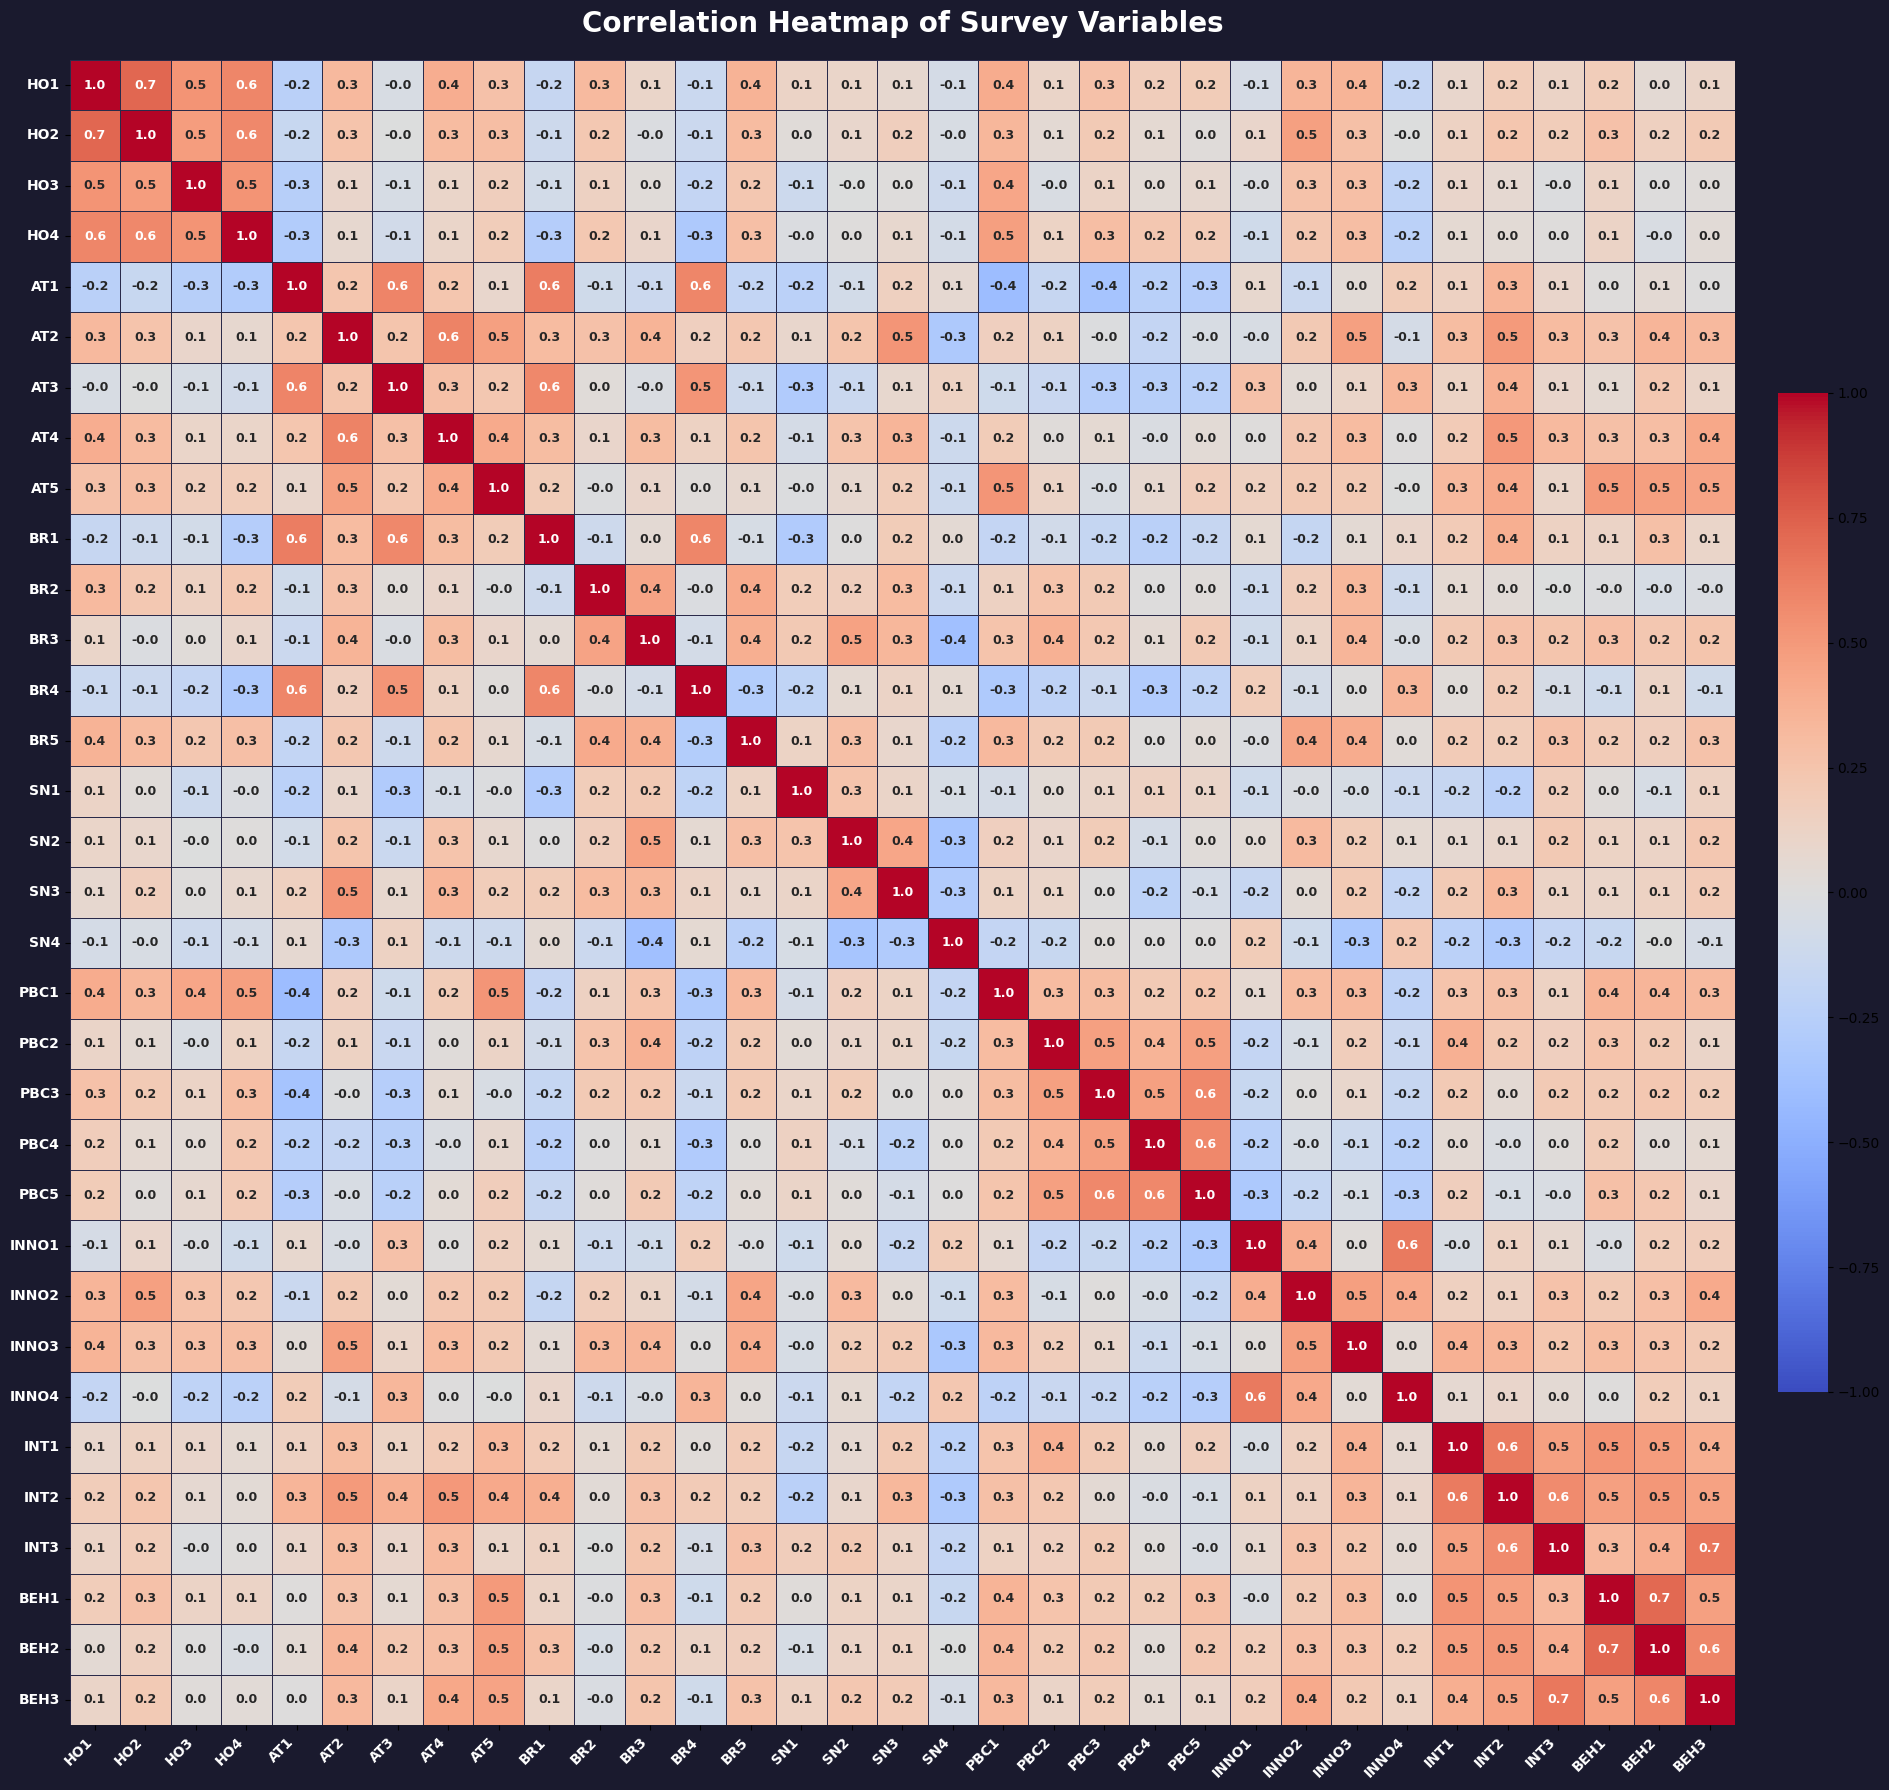

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
fig, ax = plt.subplots(figsize=(22, 18))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

sns.heatmap(
    df.corr(),
    cmap='coolwarm',          # ← back to original colormap
    vmin=-1, vmax=1,
    center=0,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 9, 'weight': 'bold'},   # auto contrast text
    linewidths=0.4,
    linecolor='#2a2a4a',
    square=True,
    cbar_kws={'shrink': 0.6, 'pad': 0.02},
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',
                   fontsize=10, color='white', fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,
                   fontsize=10, color='white', fontweight='bold')

ax.set_title('Correlation Heatmap of Survey Variables',
             fontsize=20, fontweight='bold', color='white', pad=20)

plt.tight_layout()
plt.show()

**Feature Importance Graph**

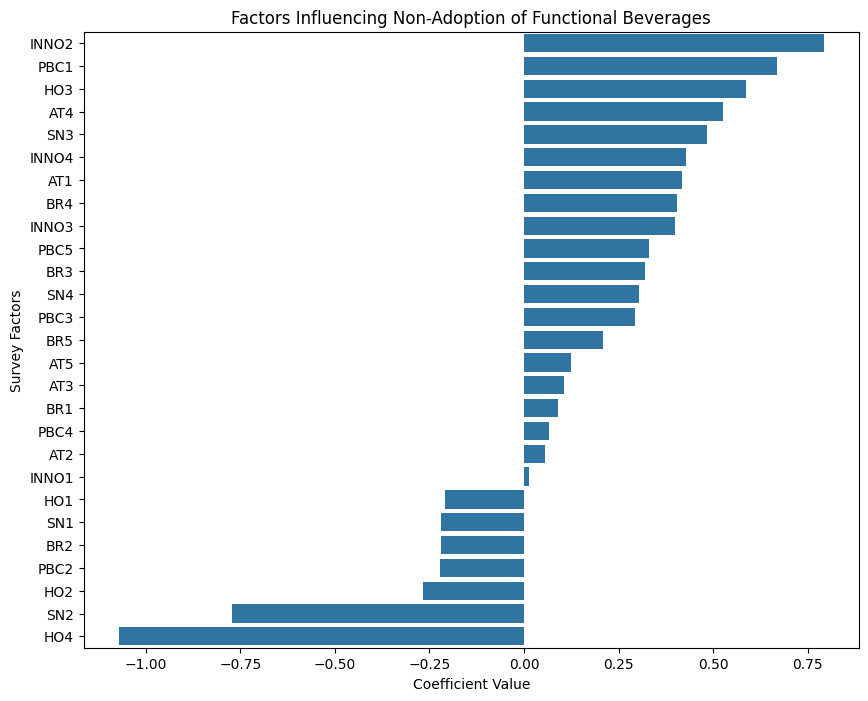

In [ ]:
importance_sorted = importance.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(
    x=importance_sorted['Coefficient'],
    y=importance_sorted['Feature']
)

plt.title("Factors Influencing Non-Adoption of Functional Beverages")
plt.xlabel("Coefficient Value")
plt.ylabel("Survey Factors")

plt.show()

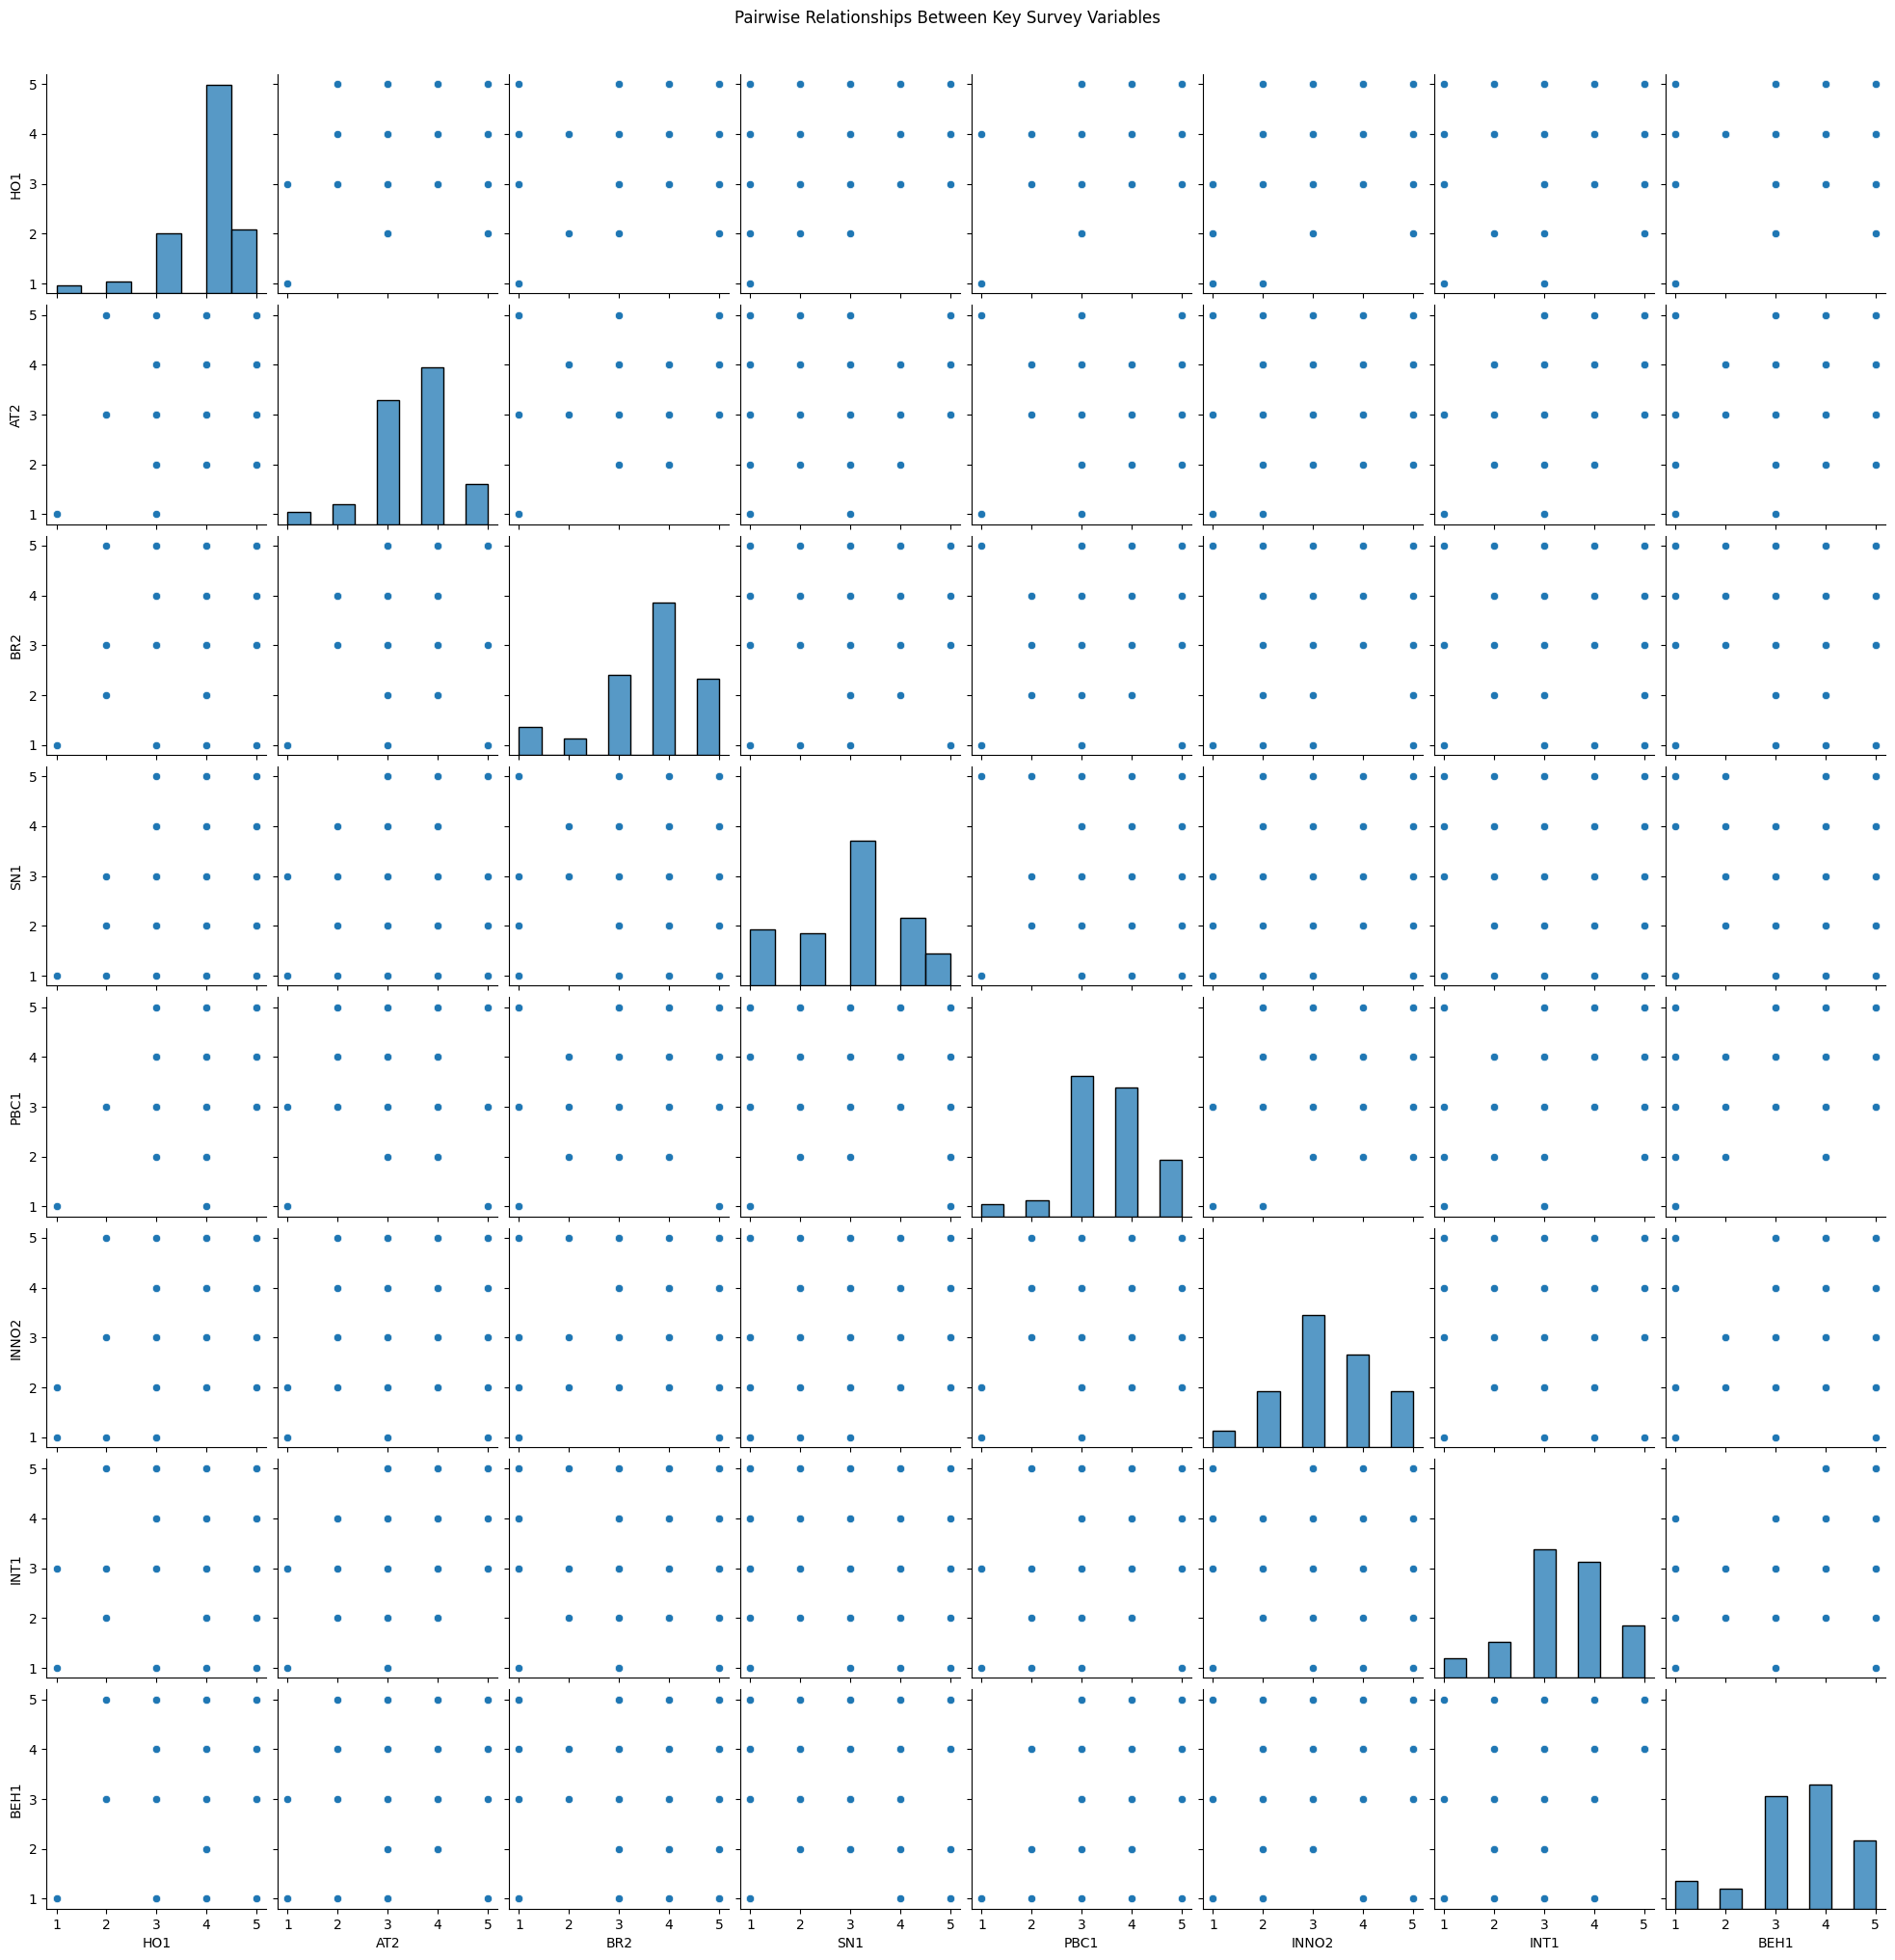

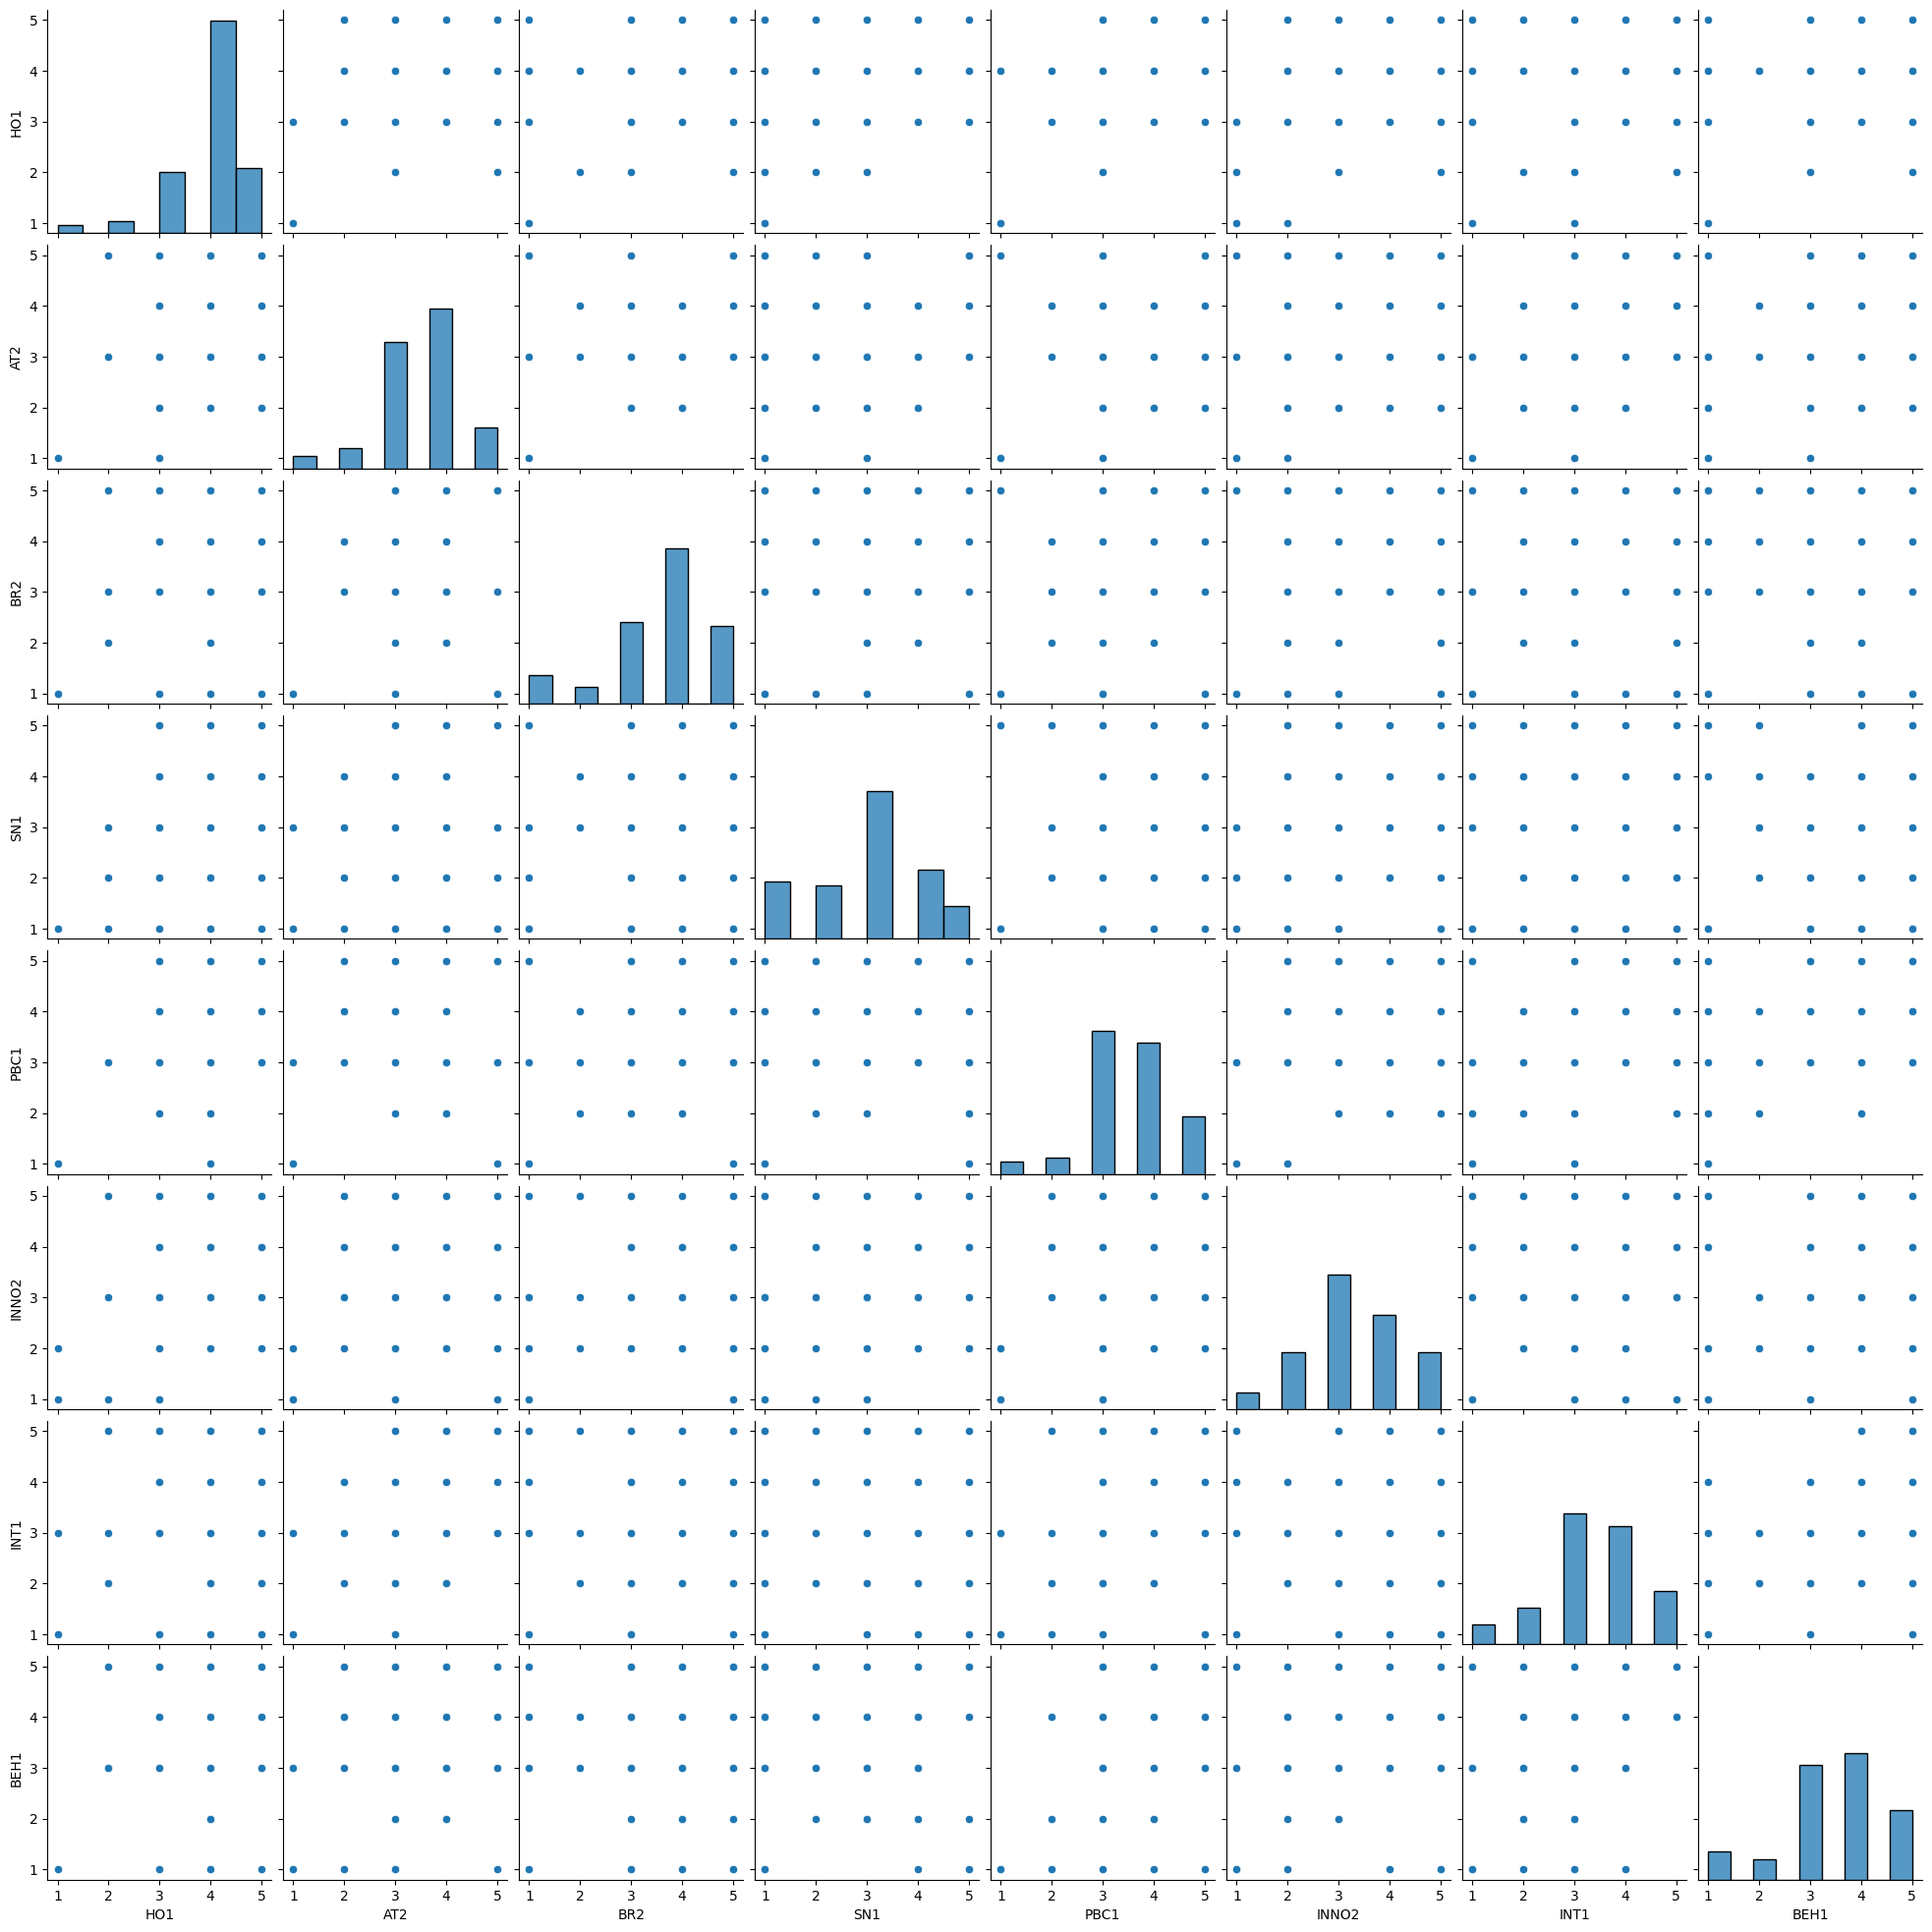

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pair_cols = ['HO1','AT2','BR2','SN1','PBC1','INNO2','INT1','BEH1']

sns.pairplot(df[pair_cols])

plt.suptitle("Pairwise Relationships Between Key Survey Variables", y=1.02)
sns.pairplot(df[pair_cols], diag_kind="hist")

plt.show()

In [ ]:
import pickle
# Save the trained model and scaler to the backend folder (portable relative path)
with open("backend/model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("backend/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Model and scaler successfully exported to backend!")